Turab Yildiz - Lighthouse Labs Final Project: Diabetes Classifier

EDA

In [ ]:
# Import required libraries

import pandas as pd

# Load the dataset (relative path adjusted)

csv_file_path = "../csvs/diabetes_012_health_indicators_BRFSS2015.csv"
data = pd.read_csv(csv_file_path)

# Display the first few rows of the dataset

print("Preview of dataset:")
display(data.head())

# Print dataset shape (rows, columns)

print(f"Dataset contains {data.shape[0]:,} rows and {data.shape[1]} columns.")

# Get summary of dataset structure

print("\nDataset Information:")
data.info()

Preview of dataset:


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Dataset contains 253,680 rows and 22 columns.

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-nul

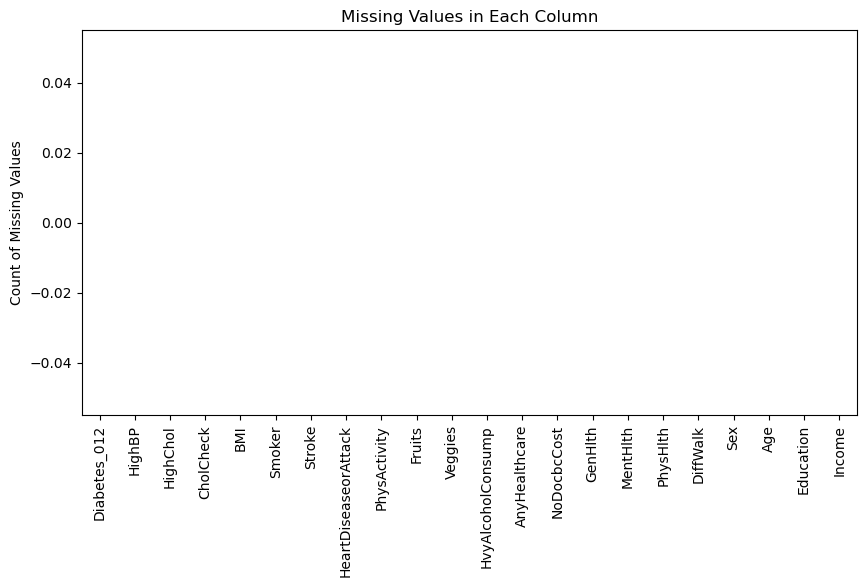

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check for missing values

missing_values = data.isnull().sum()

# Plot missing values

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_values.index, y=missing_values.values, palette="viridis")
plt.xticks(rotation=90)
plt.ylabel("Count of Missing Values")
plt.title("Missing Values in Each Column")
plt.show()


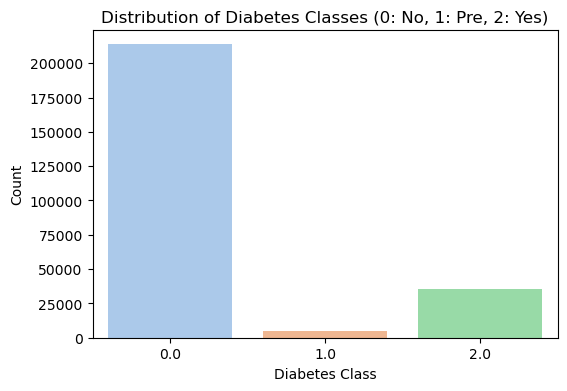

In [17]:
# Plot distribution of target variable 'Diabetes_012'

plt.figure(figsize=(6, 4))
sns.countplot(x=data["Diabetes_012"], palette="pastel")
plt.xlabel("Diabetes Class")
plt.ylabel("Count")
plt.title("Distribution of Diabetes Classes (0: No, 1: Pre, 2: Yes)")
plt.show()


It is pretty safe to assume that 0 indicates no diabetes, 1 indicates prediabetes and 2 indicates diabetes. This is said considering that prediabetes has lower prevelance than diabetes and no diabetes. After reffering to the datsets documentation, this is confirmed to be true. For the sex of the patient, 0 is female and 1 is male

The dataset seems good and there are no missing values! Time for some vizualization 

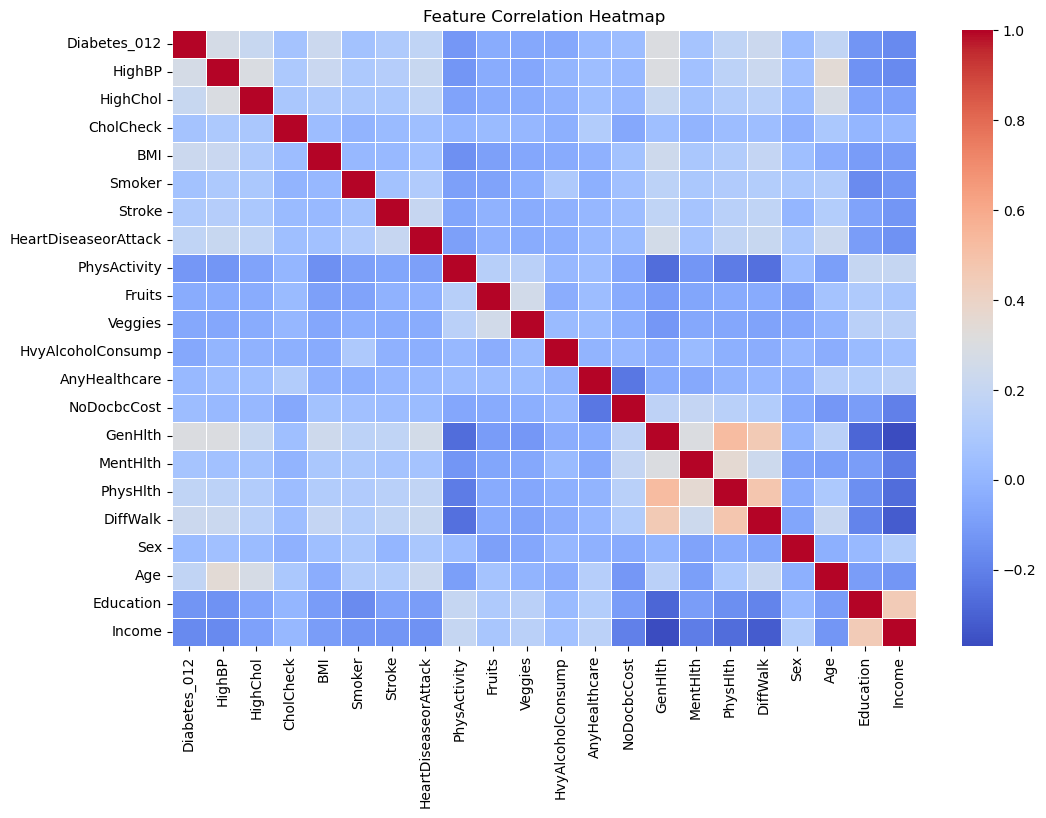

In [ ]:
# Compute correlation matrix

correlation_matrix = data.corr()

# Plot heatmap

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

From this vizualization we can tell that:

- Majority of values cluster at 0, meaning most patients do not have diabetes

- Significant number of patients have high blood pressure and cholesterol, with most patients having cholesterol checked

- Another thing to notice, most patients do not consume fruits or veggies daily

In [ ]:
# Confirm there are no missing values

if data.isnull().sum().sum() == 0:
    print("✅ No missing values detected.")

✅ No missing values detected.


In [ ]:
# Convert categorical variables to category type

categorical_columns = ["GenHlth", "Education", "Income"]
for col in categorical_columns:
    data[col] = data[col].astype("category")

# Display dataset types after conversion

print(data.dtypes)

Diabetes_012             float64
HighBP                   float64
HighChol                 float64
CholCheck                float64
BMI                      float64
Smoker                   float64
Stroke                   float64
HeartDiseaseorAttack     float64
PhysActivity             float64
Fruits                   float64
Veggies                  float64
HvyAlcoholConsump        float64
AnyHealthcare            float64
NoDocbcCost              float64
GenHlth                 category
MentHlth                 float64
PhysHlth                 float64
DiffWalk                 float64
Sex                      float64
Age                      float64
Education               category
Income                  category
dtype: object


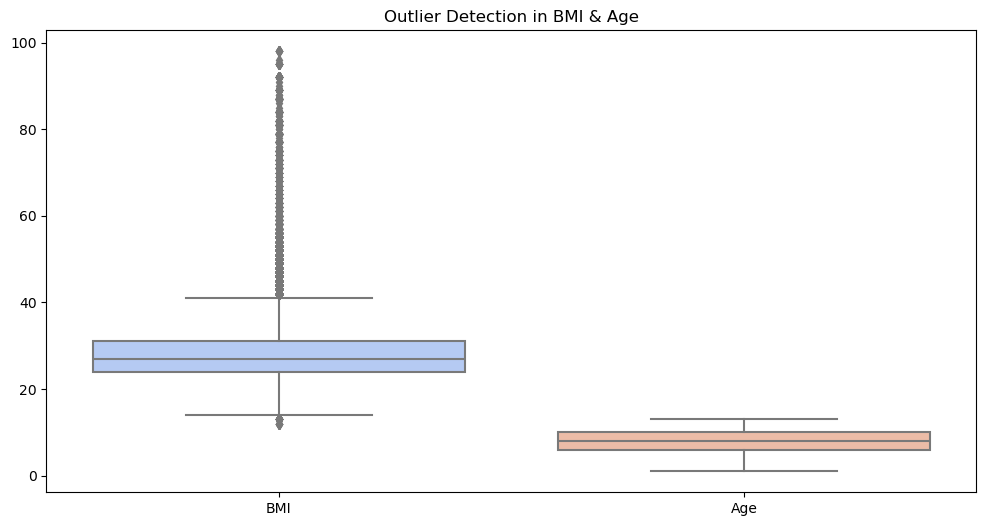

In [ ]:
# Box plot to detect outliers in key numerical features

plt.figure(figsize=(12, 6))
sns.boxplot(data=data[["BMI", "Age"]], palette="coolwarm")
plt.title("Outlier Detection in BMI & Age")
plt.show()

Some extreme outliers here. Let’s check the exact IQR values and confirm if BMI values exceed the expected range.

In [ ]:
# Calculate IQR statistics
Q1 = data["BMI"].quantile(0.25)
Q3 = data["BMI"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

# Check how many values exceed these bounds
print(f"Outliers below lower bound: {sum(data['BMI'] < lower_bound)}")
print(f"Outliers above upper bound: {sum(data['BMI'] > upper_bound)}")

Q1 (25th percentile): 24.0
Q3 (75th percentile): 31.0
IQR: 7.0
Lower Bound: 13.5
Upper Bound: 41.5
Outliers below lower bound: 0
Outliers above upper bound: 0


I will apply a hard limit for BMI at 50, just in case

In [25]:
# Apply a hard limit on BMI (remove values above 50)
filtered_data = data[data["BMI"] <= 50]

print(f"✅ Removed {len(data) - len(filtered_data)} extreme BMI values manually.")
data = filtered_data


✅ Removed 0 extreme BMI values manually.


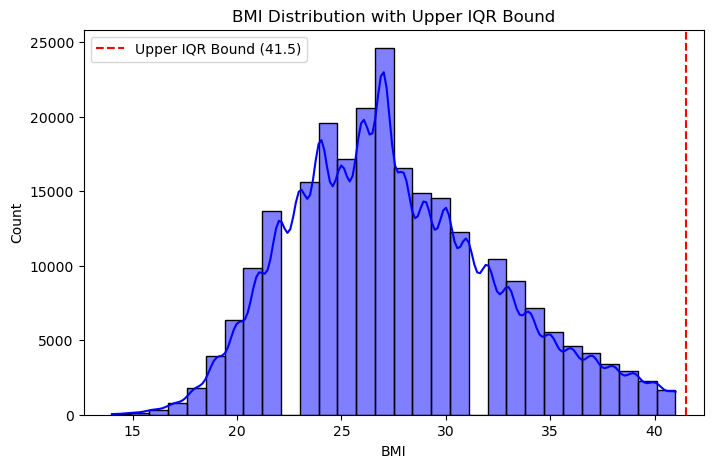

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(data["BMI"], bins=30, kde=True, color="blue")
plt.axvline(x=41.5, color='r', linestyle='--', label="Upper IQR Bound (41.5)")
plt.title("BMI Distribution with Upper IQR Bound")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.legend()
plt.show()


It seems BMI is well distrubuted. Ill check again for missing values, and save the cleaned dataset.

In [27]:
print("Missing values after processing:\n", data.isnull().sum())


Missing values after processing:
 Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [ ]:
# Save cleaned data to a new file

data.to_csv("../csvs/diabetes_cleaned.csv", index=False)
print("✅ Cleaned dataset saved as diabetes_cleaned.csv")


✅ Cleaned dataset saved as diabetes_cleaned.csv
